# kappa (residual-exponent) ablation

Sensitivity to the residual-decomposition exponent kappa (Sven only). kappa=1 is the theory; kappa=2 the default implementation.

> Loads the fresh Gram-backend results (schema 2).
>
> **MNIST label-regression only.** `cifar10_resnet_kappaScan_labelReg` and
> `cifar10_resnet_ce_kappaScan` were CUT from the campaign (ANALYSIS_PLAN section 1.2),
> so the kappa evidence is `mnist_kappaScan_labelRegression` (210 runs, matched
> effective step $2\eta/\kappa$).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/kappa'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
# MNIST only: both CIFAR kappa scans were cut from the campaign (ANALYSIS_PLAN 1.2).
SCANS={DATASET_TITLES['mnist_labelreg']:'mnist_kappaScan_labelRegression'}
data={}
for tag,name in SCANS.items():
    try: data[tag]=add_derived(load_results(name))
    except FileNotFoundError: print('missing',name)

Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)


### Best final val loss / accuracy vs kappa

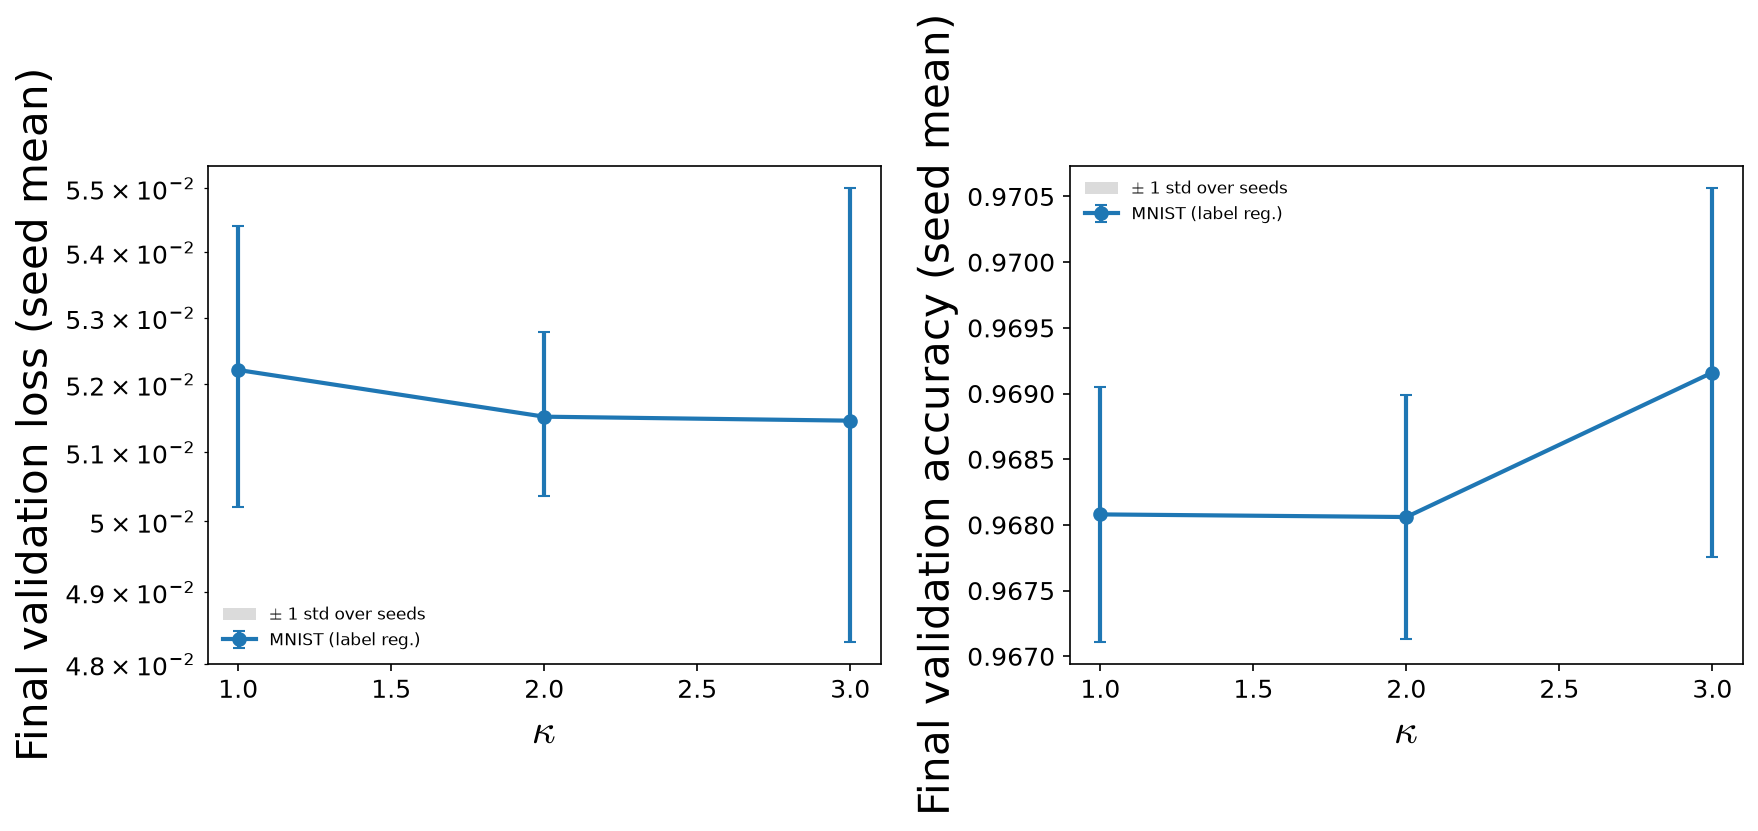

In [3]:
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for tag,df in data.items():
    # best config per kappa by SEED-MEAN val loss; error bars = seed spread
    b=seed_mean_best(df, 'kappa')
    errorbar_seeds(axes[0], b, 'kappa', 'final_val_loss', label=tag)
    if b['final_val_acc'].notna().any():
        errorbar_seeds(axes[1], b, 'kappa', 'final_val_acc', label=tag)
axes[0].set_ylabel(metric_label('final_val_loss')); axes[0].set_yscale('log')
axes[1].set_ylabel(metric_label('final_val_acc'))
for ax in axes: ax.set_xlabel('$\\kappa$'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'vs_kappa.pdf',bbox_inches='tight'); plt.show()